In [1]:
import pennylane as qp
qml = qp
import numpy as np

In [2]:
def U_power_2k(unitary, k):
    """ Computes U at a power of 2k (U^2^k)
    
    Args: 
        unitary (array[complex]): A unitary matrix
    
    Returns: 
        array[complex]: the unitary raised to the power of 2^k
    """
    ##################
    # YOUR CODE HERE #
    ##################
    return np.linalg.matrix_power(unitary, 2**k)

# Try out a higher power of U
U = qp.T.compute_matrix()
print(U)

U_power_2k(U, 2)

[[1.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.70710678+0.70710678j]]


array([[ 1.+0.00000000e+00j,  0.+0.00000000e+00j],
       [ 0.+0.00000000e+00j, -1.+3.99346924e-16j]])

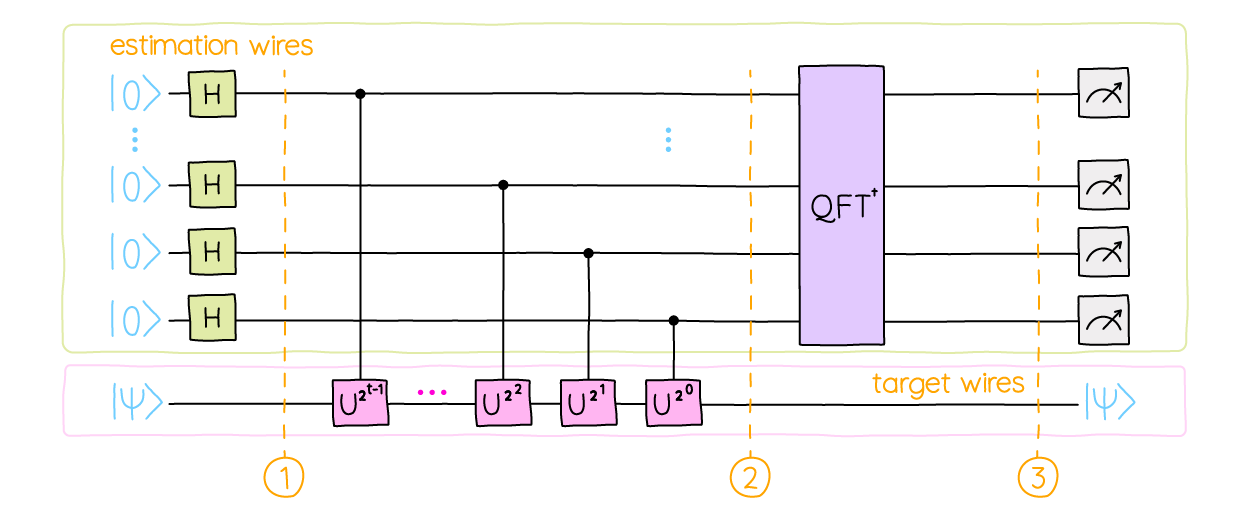

In [3]:
estimation_wires = [0, 1, 2]
target_wires = [3]

def apply_controlled_powers_of_U(unitary):
    """A quantum function that applies the sequence of powers of U^2^k to
    the estimation wires.
    
    Args: 
        unitary (array [complex]): A unitary matrix
    """

    ##################
    # YOUR CODE HERE #
    ##################  
    # qp.ControlledSequence(qp.QubitUnitary(unitary, wires=3), control = estimation_wires)
    for k in estimation_wires:
        U = U_power_2k(unitary, len(estimation_wires)-k-1)
        qp.ControlledQubitUnitary(U, wires = [k] + target_wires)

In [4]:
dev = qp.device("default.qubit", wires=4)

estimation_wires = [0, 1, 2]
target_wires = [3]

def prepare_eigenvector(target_wires):
    qp.PauliX(wires=target_wires)

@qp.qnode(dev)
def qpe(unitary):
    """ Estimate the phase for a given unitary.
    
    Args:
        unitary (array[complex]): A unitary matrix.
        
    Returns:
        array[float]: Measurement outcome probabilities on the estimation wires.
    """
    ##################
    # YOUR CODE HERE #
    ##################
    prepare_eigenvector(target_wires)
    
    for wire in estimation_wires:
        qp.Hadamard(wires=wire)
        
    apply_controlled_powers_of_U(unitary)
    
    qp.adjoint(qp.QFT)(wires=estimation_wires)

    return qp.probs(wires=estimation_wires)
    
U = qp.T.compute_matrix()
print(qpe(U))

[8.54017922e-33 1.00000000e+00 1.73012985e-32 3.46667390e-33
 3.35150719e-33 4.28519413e-33 2.90023373e-33 4.81482486e-33]


In [5]:
estimation_wires = [0, 1, 2]
target_wires = [3]

def estimate_phase(probs):
    """Estimate the value of a phase given measurement outcome probabilities
    of the QPE routine.
    
    Args: 
        probs (array[float]): Probabilities on the estimation wires.
    
    Returns:
        float: the estimated phase   
    """
    ##################
    # YOUR CODE HERE #
    ##################
    return np.argmax(probs) / 2 ** len(estimation_wires)

U = qp.T.compute_matrix()

probs = qpe(U)

estimated_phase = estimate_phase(probs)
print(estimated_phase)

0.125


In [6]:
dev = qp.device("default.qubit", wires=4)

estimation_wires = [0, 1, 2]
target_wires = [3]

def prepare_eigenvector():
    qp.PauliX(wires=target_wires)

@qp.qnode(dev)
def qpe(unitary):
    """Estimate the phase for a given unitary.
    
    Args:
        unitary (array[complex]): A unitary matrix.
        
    Returns:
        array[float]: Probabilities on the estimation wires.
    """
    
    prepare_eigenvector()
    
    ##################
    # YOUR CODE HERE #
    ################## 
    qp.QuantumPhaseEstimation(unitary, 
                              target_wires=target_wires, 
                              estimation_wires=estimation_wires)
    
    return qp.probs(wires=estimation_wires)

U = qp.T.compute_matrix()
probs = qpe(U)
print(estimate_phase(probs))

0.125
